In [1]:
import torch
import torch.nn.functional as F
import torch_geometric.typing
from torch_geometric.datasets import PPI
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, GATConv
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
import numpy as np

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

C:\Users\Vertx\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cpu


## 1. Data Loading
PPI consists of 20 training graphs, 2 validation graphs, and 2 test graphs. We use `DataLoader` to batch these graphs during training.

In [2]:
def load_ppi_data():
    path = './data/PPI'
    train_dataset = PPI(path, split='train')
    val_dataset = PPI(path, split='val')
    test_dataset = PPI(path, split='test')

    train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=2, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=2, shuffle=False)

    print(f'Number of training graphs: {len(train_dataset)}')
    print(f'Number of validation graphs: {len(val_dataset)}')
    print(f'Number of test graphs: {len(test_dataset)}')
    print(f'Number of features: {train_dataset.num_features}')
    print(f'Number of classes: {train_dataset.num_classes}')
    
    return train_loader, val_loader, test_loader, train_dataset.num_features, train_dataset.num_classes

train_loader, val_loader, test_loader, num_features, num_classes = load_ppi_data()

Extracting data\PPI\ppi.zip
Processing...


Number of training graphs: 20
Number of validation graphs: 2
Number of test graphs: 2
Number of features: 50
Number of classes: 121


Done!


## 2. Model Definitions

### GCN (Graph Convolutional Network)
A standard 3-layer GCN. Note that for multi-label classification, we do **not** apply Softmax at the end. We output raw logits.

In [3]:
class GCN_PPI(torch.nn.Module):
    def __init__(self, num_features, num_classes, hidden_channels=256):
        super(GCN_PPI, self).__init__()
        self.conv1 = GCNConv(num_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, num_classes)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = self.conv3(x, edge_index)
        return x  # Return logits (BCEWithLogitsLoss handles sigmoid)

### GAT (Graph Attention Network)
A 3-layer GAT model matching the architecture described in the original paper for PPI.
*   Layer 1 & 2: 4 Attention Heads
*   Layer 3: 6 Attention Heads (Averaged)
*   Skip connections are often used in deeper GATs.

In [4]:
class GAT_PPI(torch.nn.Module):
    def __init__(self, num_features, num_classes, hidden_channels=256, heads=4):
        super(GAT_PPI, self).__init__()
        self.conv1 = GATConv(num_features, hidden_channels, heads=heads)
        self.conv2 = GATConv(hidden_channels * heads, hidden_channels, heads=heads)
        self.conv3 = GATConv(hidden_channels * heads, num_classes, heads=6, concat=False)

    def forward(self, x, edge_index):
        x = F.elu(self.conv1(x, edge_index))
        x = F.elu(self.conv2(x, edge_index))
        x = self.conv3(x, edge_index)
        return x # Return logits

## 3. Training and Evaluation Loop
*   **Loss Function**: `BCEWithLogitsLoss` (Binary Cross Entropy) because this is a multi-label problem.
*   **Metric**: Micro-F1 Score.

In [5]:
def train(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    for data in loader:
        data = data.to(device)
        optimizer.zero_grad()
        out = model(data.x, data.edge_index)
        loss = criterion(out, data.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * data.num_graphs
    return total_loss / len(loader.dataset)

@torch.no_grad()
def test(model, loader):
    model.eval()
    ys, preds = [], []
    for data in loader:
        data = data.to(device)
        out = model(data.x, data.edge_index)
        preds.append((out > 0).float().cpu())
        ys.append(data.y.cpu())
    
    y, pred = torch.cat(ys, dim=0).numpy(), torch.cat(preds, dim=0).numpy()
    return f1_score(y, pred, average='micro')

def run_ppi_experiment(model, epochs=100, lr=0.005):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = torch.nn.BCEWithLogitsLoss()
    
    train_losses = []
    val_f1s = []
    test_f1s = []
    
    print(f"Training {type(model).__name__}...")
    for epoch in range(1, epochs + 1):
        loss = train(model, train_loader, optimizer, criterion)
        val_f1 = test(model, val_loader)
        test_f1 = test(model, test_loader)
        
        train_losses.append(loss)
        val_f1s.append(val_f1)
        test_f1s.append(test_f1)
        
        if epoch % 10 == 0:
            print(f'Epoch: {epoch:03d}, Loss: {loss:.4f}, Val F1: {val_f1:.4f}, Test F1: {test_f1:.4f}')
            
    return train_losses, val_f1s, test_f1s

## 4. Experiment Execution

In [7]:
# Train GCN
gcn_model = GCN_PPI(num_features, num_classes).to(device)
gcn_losses, gcn_val_f1, gcn_test_f1 = run_ppi_experiment(gcn_model, epochs=100, lr=0.005)
print(f"Final GCN Test F1: {gcn_test_f1[-1]:.4f}")

Training GCN_PPI...
Epoch: 010, Loss: 0.5320, Val F1: 0.5132, Test F1: 0.5258
Epoch: 020, Loss: 0.4946, Val F1: 0.5056, Test F1: 0.5149
Epoch: 030, Loss: 0.4748, Val F1: 0.5591, Test F1: 0.5675
Epoch: 040, Loss: 0.4613, Val F1: 0.5808, Test F1: 0.5893
Epoch: 050, Loss: 0.4576, Val F1: 0.5792, Test F1: 0.5908
Epoch: 060, Loss: 0.4497, Val F1: 0.5636, Test F1: 0.5761
Epoch: 070, Loss: 0.4418, Val F1: 0.5937, Test F1: 0.6051
Epoch: 080, Loss: 0.4387, Val F1: 0.6112, Test F1: 0.6215
Epoch: 090, Loss: 0.4311, Val F1: 0.6103, Test F1: 0.6202
Epoch: 100, Loss: 0.4295, Val F1: 0.5963, Test F1: 0.6101
Final GCN Test F1: 0.6101


In [8]:
# Train GAT
gat_model = GAT_PPI(num_features, num_classes).to(device)
gat_losses, gat_val_f1, gat_test_f1 = run_ppi_experiment(gat_model, epochs=100, lr=0.005)
print(f"Final GAT Test F1: {gat_test_f1[-1]:.4f}")

Training GAT_PPI...
Epoch: 010, Loss: 0.4670, Val F1: 0.5378, Test F1: 0.5429
Epoch: 020, Loss: 0.3911, Val F1: 0.6660, Test F1: 0.6930
Epoch: 030, Loss: 0.3047, Val F1: 0.7180, Test F1: 0.7556
Epoch: 040, Loss: 0.2251, Val F1: 0.7938, Test F1: 0.8290
Epoch: 050, Loss: 0.1904, Val F1: 0.8077, Test F1: 0.8447
Epoch: 060, Loss: 0.1410, Val F1: 0.8441, Test F1: 0.8804
Epoch: 070, Loss: 0.1119, Val F1: 0.8759, Test F1: 0.9095
Epoch: 080, Loss: 0.1116, Val F1: 0.8724, Test F1: 0.9059
Epoch: 090, Loss: 0.0878, Val F1: 0.8937, Test F1: 0.9247
Epoch: 100, Loss: 0.0693, Val F1: 0.8982, Test F1: 0.9280
Final GAT Test F1: 0.9280


## 5. Comparison

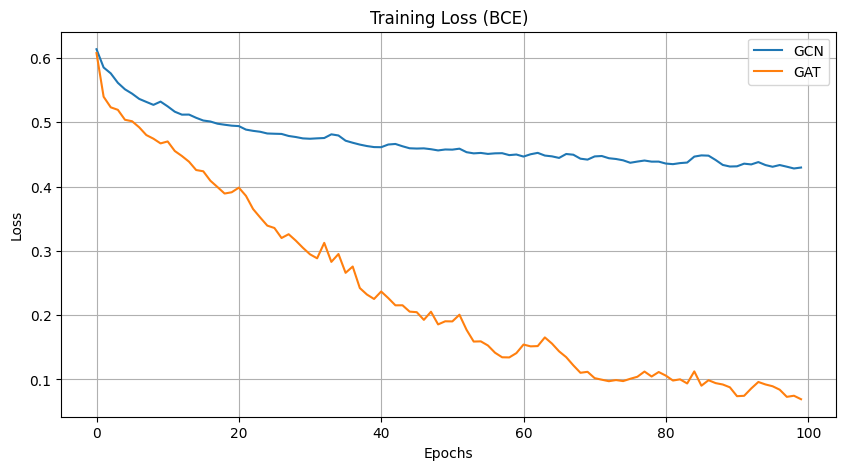

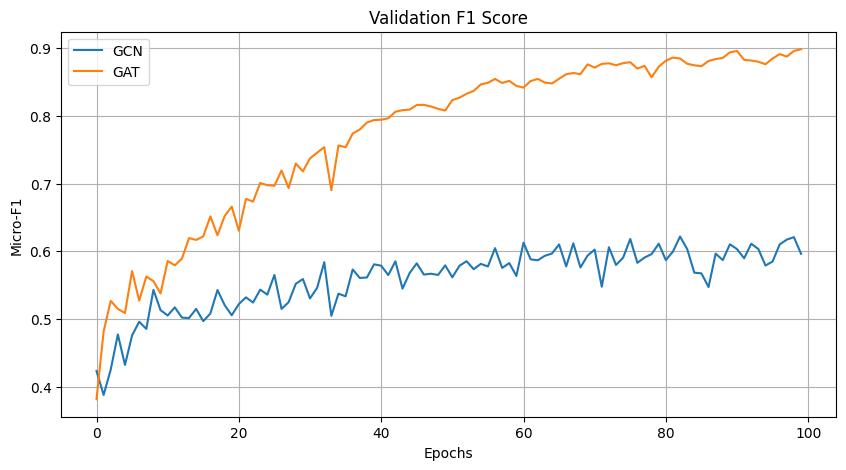

In [9]:
def plot_ppi_results(gcn_data, gat_data, title, ylabel):
    plt.figure(figsize=(10, 5))
    plt.plot(gcn_data, label='GCN')
    plt.plot(gat_data, label='GAT')
    plt.title(title)
    plt.xlabel('Epochs')
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(True)
    plt.show()

plot_ppi_results(gcn_losses, gat_losses, 'Training Loss (BCE)', 'Loss')
plot_ppi_results(gcn_val_f1, gat_val_f1, 'Validation F1 Score', 'Micro-F1')